In [1]:
import numpy as np
import pandas as pd
import sys, os

from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

from pyfrechet.metric_spaces import MetricData, Euclidean
from pyfrechet.regression.bagged_regressor import BaggedRegressor
from sklearn.preprocessing import MinMaxScaler


INFO: Using numpy backend


## Functions

In [135]:
def coverage_results(M, sign_level):
    """ Compute empirical quantiles for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'x_train_data', 'y_train_data', 'x_test_data', 'y_test_data', 'test_predictions', 'residuals'])
    
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conformal_results')):
        if file.endswith('.npy'):
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conformal_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        sample_index = int(file.split('_')[1][4:])
        train_size = int(file.split('_')[2][1:])
        sigma = file.split('_')[3][5:]
        
        test_preds = result['forest'].predict(result['x_test_data'])
        
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': sample_index,
            'train_size': train_size,
            'sigma': sigma,
            'x_train_data': [result['x_train_data']],
            'y_train_data': [result['y_train_data']],
            'x_test_data': [result['x_test_data']],
            'y_test_data': [result['y_test_data']],
            'test_predictions': [test_preds],
            'forest': [result['forest']],
            'residuals': [M.d(result['y_test_data'], test_preds)]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

        coverage_df['quantiles'] = coverage_df['residuals'].apply(lambda r: np.percentile(r, (1 - np.array([sign_level])) * 100, method='inverted_cdf'))
        coverage_df['quantiles'] = coverage_df['quantiles'].apply(lambda x: x[0])
    return coverage_df


# Function to simulate multivariate regression data
def simulate_data(sigma, X_design, betas):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a multivariate normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size)
    
    # Step 2: Apply the model transformations
    X_1 = X_design[:, 1]  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 2]  # X_2 corresponds to the second column
    X_3 = X_design[:, 3]  # X_3 corresponds to the third column
    X_4 = X_design[:, 4]  # X_4 corresponds to the fourth column
    X_5 = X_design[:, 5]  # X_5 corresponds to the fifth column

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*sin(pi*X_2) + beta_3*X_3^2 + beta_4*X_2*X_4 + beta_5*X_5 + epsilon
    sin_X2 = np.sin(np.pi * X_2)  # Apply sin to X_2
    X_3_squared = X_3 ** 2  # Apply square to X_3
    X_2_X_4 = X_2 * X_4  # Interaction term between X_2 and X_4

    Ys = betas[0] + betas[1] * X_1 + betas[2] * sin_X2 + betas[3] * X_3_squared + betas[4] * X_2_X_4 + betas[5] * X_5 + epsilon
            
    # Convert list to array for easier manipulation
    Ys = np.array(Ys).reshape(sample_size, 1)
    
    # Center the predictors
    #X_design -= X_design.mean(axis=0)
    
    # Center the responses
    #Ys -= Ys.mean(axis=0)
    
    return X_design[:,1:], Ys

### Read the data

In [121]:
# Define confidence levels
np.random.seed(1000)
sign_level = [0.01, 0.05, 0.1]
betas = np.array([-1, -1, 2, -3, 3, -1])  # Define the true beta values
M = Euclidean(dim = 1)
# Load stored results
results_dir = os.path.join(os.getcwd(), 'simulations_euc', 'conformal_results')
sigmas = [0.1, 0.3, 0.5]
coverage_df_euc=coverage_results(M=M, sign_level=sign_level)
coverage_df_euc.head()

,sample_index,train_size,sigma,x_train_data,y_train_data,train_predictions,x_test_data,y_test_data,test_predictions,residuals,forest,quantiles
0,33,200,0.1,"[[0.7395884793432653, 0.6693394334136951, 0.06...","([2.149990142208994], [1.088787413191077], [1....",NaN,"[[0.3265947852187776, 0.5482745989941231, 0.36...","([1.5032662082600579], [-0.685633088950402], [...","([0.7747193340445571], [-0.5147280807310177], ...","[0.7285468742155008, 0.17090500821938426, 0.47...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.4698726595348766, 1.319394723884617, 1.1598..."
1,22,500,0.5,"[[0.7660747330386279, 0.874842241692091, 0.715...","([-0.9546853799100476], [-1.5038033989758028],...",NaN,"[[0.014901792994685754, 0.3680643632410456, 0....","([1.8635527910596643], [-0.03531888281596868],...","([0.7830309697581318], [-0.5575395915372015], ...","[1.0805218213015326, 0.5222207087212327, 1.071...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.2499577447425714, 1.704329340802661, 1.3685..."
2,35,200,0.3,"[[0.6889950251636495, 0.06795633566665091, 0.4...","([-1.1311610552365545], [-1.004213479669268], ...",NaN,"[[0.8612893428945011, 0.099370374155555, 0.984...","([-2.9287850366880273], [-1.323383707051214], ...","([-1.300342321673621], [-1.2396716215631227], ...","[1.6284427150144063, 0.08371208548809128, 1.14...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.076720287935, 1.8377846994996054, 1.4992635..."
3,30,100,0.5,"[[0.9186403928008772, 0.150405719539191, 0.169...","([0.12064455029281457], [-2.5138788161501795],...",NaN,"[[0.317510905741294, 0.2923793983138011, 0.841...","([-1.3193826162953903], [-0.6228819724094027],...","([-0.8617321952939014], [-0.8027907996889487],...","[0.4576504210014889, 0.17990882727954605, 0.22...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.3008857545262105, 1.5972952473640556, 1.370..."
4,48,200,0.5,"[[0.2625807623174815, 0.016217438531158528, 0....","([-1.0369588585485137], [-0.4096651445222883],...",NaN,"[[0.00779988832449378, 0.4128882202286176, 0.2...","([0.904431429765673], [1.6442614848443613], [-...","([0.6130661389149838], [0.9298157890020337], [...","[0.2913652908506892, 0.7144456958423276, 1.670...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.2793471972043755, 1.6704529443179676, 1.362..."


# TYPE I

In [122]:
MC = 49
n_estimations = 50
n_predictors = 5

zeros_init = np.zeros(shape = (n_estimations, 3))
cov = np.zeros(shape = (n_estimations, 3))

diccionario = {
    'sigma_0.1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.3': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
}

# Obtain n_estimations estimations of Type I coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.1, 0.3, 0.5]:

    coverage_df = coverage_df_euc[coverage_df_euc['sigma'] == str(sigma)]
    M = Euclidean(dim = 1)
    
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        coverage_df_N = coverage_df[coverage_df['train_size'] == N]
        for estimation in range(n_estimations):
            yesno = np.zeros(3)
            # Randomly select rows from the dataframe
            new_X_design = np.random.uniform(0, 1, size = (MC, n_predictors))
            # Add a column of ones for the intercept (beta_0)
            new_X_design = np.c_[np.ones(MC), new_X_design]
            new_X_design, new_ys = simulate_data(sigma = sigma, X_design=new_X_design, betas=betas)
            lns = coverage_df_N.sample(n=MC, replace=False)
    
            i = 0
            for _, ln in lns.iterrows():
                # Generate one random point to test if it belongs to the CI_region
                new_X = new_X_design[i,:].reshape(1, n_predictors)

                #Predict the new observation
                new_pred = ln['forest'].predict(new_X)
                new_y = new_ys[i]

                # Store the selected values
                yesno = np.vstack((yesno, M.d(new_pred, new_y) <= ln['quantiles']))
                i += 1
            cov[estimation, :] = yesno[1:,:].sum(axis=0) / MC
            
        diccionario['sigma_'+str(sigma)][str(N)] = np.copy(cov)

In [123]:
for sigma in [0.1, 0.3, 0.5]:    
        for N in [50, 100, 200, 500]:
            print(f"sigma = {sigma}, N = {N}, mean of Type I coverage estimates: ", np.mean(diccionario['sigma_'+str(sigma)][str(N)], axis = 0)) 
            print(f"sigma = {sigma}, N = {N}, standard deviation of Type I coverage estimates: ", np.sqrt(np.var(diccionario['sigma_'+str(sigma)][str(N)], axis = 0))  )    

sigma = 0.1, N = 50, mean of Type I coverage estimates:  [0.95714286 0.92204082 0.87959184]
sigma = 0.1, N = 50, standard deviation of Type I coverage estimates:  [0.0277581  0.04034214 0.04127296]
sigma = 0.1, N = 100, mean of Type I coverage estimates:  [0.97673469 0.94122449 0.88979592]
sigma = 0.1, N = 100, standard deviation of Type I coverage estimates:  [0.0238033  0.03281592 0.04414961]
sigma = 0.1, N = 200, mean of Type I coverage estimates:  [0.97877551 0.94040816 0.89183673]
sigma = 0.1, N = 200, standard deviation of Type I coverage estimates:  [0.01955779 0.03286665 0.04850965]
sigma = 0.1, N = 500, mean of Type I coverage estimates:  [0.98816327 0.95061224 0.88857143]
sigma = 0.1, N = 500, standard deviation of Type I coverage estimates:  [0.01585545 0.03001874 0.04639615]
sigma = 0.3, N = 50, mean of Type I coverage estimates:  [0.96653061 0.93020408 0.89510204]
sigma = 0.3, N = 50, standard deviation of Type I coverage estimates:  [0.02440803 0.03163989 0.04020149]
sigm

In [92]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.1, 0.3, 0.5]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

Significance Level           0.01           0.05            0.1
sigma N                                                        
0.1   50            100.00 (0.00)  100.00 (0.00)  100.00 (0.00)
      100           100.00 (0.00)  100.00 (0.00)  100.00 (0.00)
      200           100.00 (0.00)  100.00 (0.00)  100.00 (0.00)
      500           100.00 (0.00)  100.00 (0.00)  100.00 (0.00)
0.3   50            100.00 (0.00)   99.92 (0.40)   99.63 (0.88)
      100           100.00 (0.00)  100.00 (0.00)   99.96 (0.29)
      200           100.00 (0.00)  100.00 (0.00)  100.00 (0.00)
      500           100.00 (0.00)  100.00 (0.00)   99.92 (0.40)
0.5   50             99.80 (0.61)   99.43 (1.00)   98.73 (1.82)
      100           100.00 (0.00)   99.92 (0.40)   98.90 (1.48)
      200           100.00 (0.00)   99.88 (0.48)   99.18 (1.22)
      500           100.00 (0.00)   99.76 (0.78)   98.94 (1.37)

In [25]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error coverage for different distances, degrees of freedom and sample sizes', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/2260981167.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [26]:
print(latex)

\begin{table}
\caption{Type I error coverage for different distances, degrees of freedom and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.1}} & \textbf{50} & 96.29 (2.60) & 93.31 (3.51) & 88.86 (4.32) \\
\textbf{} & \textbf{100} & 98.33 (1.62) & 94.00 (2.98) & 88.73 (4.00) \\
\textbf{} & \textbf{200} & 98.37 (2.16) & 93.39 (3.38) & 87.22 (4.26) \\
\textbf{} & \textbf{500} & 98.86 (1.64) & 94.16 (3.44) & 88.37 (4.97) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.3}} & \textbf{50} & 96.53 (2.32) & 93.18 (2.99) & 89.96 (3.93) \\
\textbf{} & \textbf{100} & 98.12 (2.07) & 93.76 (3.92) & 88.00 (4.81) \\
\textbf{} & \textbf{200} & 98.57 (1.65) & 94.73 (3.42) & 89.10 (3.62) \\
\textbf{} & \textbf{500} & 98.33 (2.30) & 94.41 (4.30) & 89.71 (5.10) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.5}} & \textbf{50} & 95.96 (2.66) & 91.55 (3.54) & 87.18 (4

# TYPE II

In [57]:
coverage_df_euc['II_coverage'] = [[0, 0, 0] for _ in range(len(coverage_df_euc))]
MC = 500

np.random.seed(1000)

#Calculate coverage for every dataset L_n (Type IV):
for i, ln in coverage_df_euc.iterrows():
    #Generate observations to estimate the probability
    new_X_design = np.random.uniform(size = (MC, n_predictors))
    new_X_design = np.c_[np.ones(MC), new_X_design]
    new_X, new_y = simulate_data(sigma = float(ln['sigma']), X_design=new_X_design, betas = betas)
    
    new_y = MetricData(M, np.array(new_y))

    new_pred = ln['forest'].predict(new_X)

    coverage_df_euc.at[i, 'II_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['quantiles'], (MC, 1)), axis = 0) / MC

In [58]:
ii_coverage_df_euc_alpha_01 = coverage_df_euc.copy()
ii_coverage_df_euc_alpha_05 = coverage_df_euc.copy()
ii_coverage_df_euc_alpha_1 = coverage_df_euc.copy()

ii_coverage_df_euc_alpha_01['II_coverage'] = coverage_df_euc['II_coverage'].apply(lambda x: x[0])
ii_coverage_df_euc_alpha_01['quantiles'] = coverage_df_euc['quantiles'].apply(lambda x: x[0])

ii_coverage_df_euc_alpha_05['II_coverage'] = coverage_df_euc['II_coverage'].apply(lambda x: x[1])
ii_coverage_df_euc_alpha_05['quantiles'] = coverage_df_euc['quantiles'].apply(lambda x: x[1])

ii_coverage_df_euc_alpha_1['II_coverage'] = coverage_df_euc['II_coverage'].apply(lambda x: x[2])
ii_coverage_df_euc_alpha_1['quantiles'] = coverage_df_euc['quantiles'].apply(lambda x: x[2])

ii_coverage_df_euc_alpha_01.head()
ii_coverage_df_euc_alpha_05.head()
ii_coverage_df_euc_alpha_1.head()

,sample_index,train_size,sigma,x_train_data,y_train_data,train_predictions,x_test_data,y_test_data,test_predictions,residuals,forest,quantiles,II_coverage
0,33,200,0.1,"[[0.7395884793432653, 0.6693394334136951, 0.06...","([2.149990142208994], [1.088787413191077], [1....",NaN,"[[0.3265947852187776, 0.5482745989941231, 0.36...","([1.5032662082600579], [-0.685633088950402], [...","([0.7747193340445571], [-0.5147280807310177], ...","[0.7285468742155008, 0.17090500821938426, 0.47...","BaggedRegressor(bootstrap_fraction=1, bootstra...",1.159896,0.882
1,22,500,0.5,"[[0.7660747330386279, 0.874842241692091, 0.715...","([-0.9546853799100476], [-1.5038033989758028],...",NaN,"[[0.014901792994685754, 0.3680643632410456, 0....","([1.8635527910596643], [-0.03531888281596868],...","([0.7830309697581318], [-0.5575395915372015], ...","[1.0805218213015326, 0.5222207087212327, 1.071...","BaggedRegressor(bootstrap_fraction=1, bootstra...",1.368544,0.916
2,35,200,0.3,"[[0.6889950251636495, 0.06795633566665091, 0.4...","([-1.1311610552365545], [-1.004213479669268], ...",NaN,"[[0.8612893428945011, 0.099370374155555, 0.984...","([-2.9287850366880273], [-1.323383707051214], ...","([-1.300342321673621], [-1.2396716215631227], ...","[1.6284427150144063, 0.08371208548809128, 1.14...","BaggedRegressor(bootstrap_fraction=1, bootstra...",1.499264,0.938
3,30,100,0.5,"[[0.9186403928008772, 0.150405719539191, 0.169...","([0.12064455029281457], [-2.5138788161501795],...",NaN,"[[0.317510905741294, 0.2923793983138011, 0.841...","([-1.3193826162953903], [-0.6228819724094027],...","([-0.8617321952939014], [-0.8027907996889487],...","[0.4576504210014889, 0.17990882727954605, 0.22...","BaggedRegressor(bootstrap_fraction=1, bootstra...",1.370192,0.862
4,48,200,0.5,"[[0.2625807623174815, 0.016217438531158528, 0....","([-1.0369588585485137], [-0.4096651445222883],...",NaN,"[[0.00779988832449378, 0.4128882202286176, 0.2...","([0.904431429765673], [1.6442614848443613], [-...","([0.6130661389149838], [0.9298157890020337], [...","[0.2913652908506892, 0.7144456958423276, 1.670...","BaggedRegressor(bootstrap_fraction=1, bootstra...",1.362202,0.896


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/1038711178.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


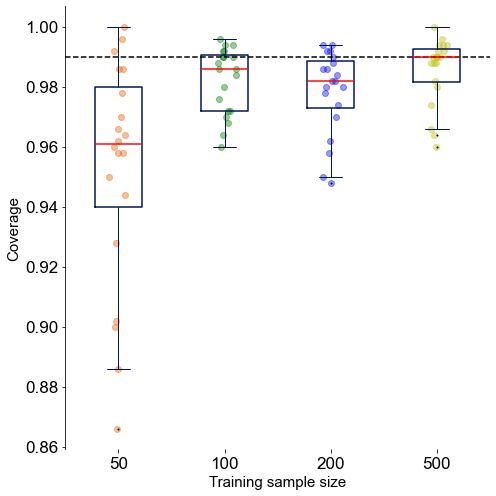

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/1038711178.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


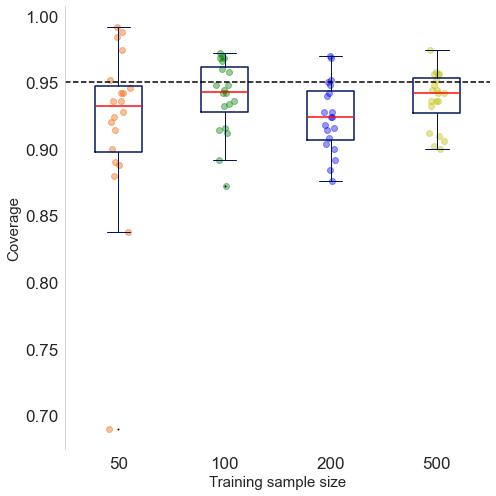

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/1038711178.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


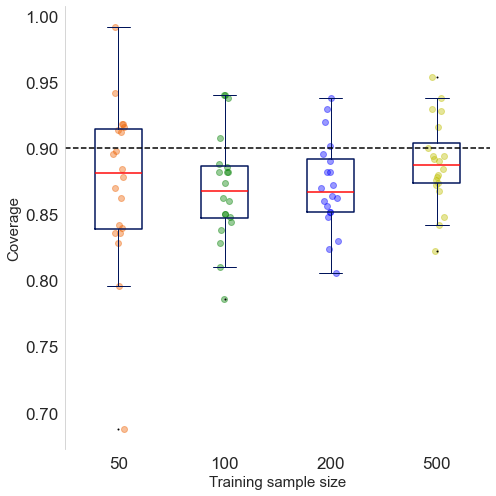

In [59]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_coverage_df_euc_alpha_01, ii_coverage_df_euc_alpha_05, ii_coverage_df_euc_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50].iloc[0:20]
    data_100 = data[data['train_size'] == 100].iloc[0:20]
    data_200 = data[data['train_size'] == 200].iloc[0:20]
    data_500 = data[data['train_size'] == 500].iloc[0:20]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    ax.set_xlabel('Training sample size', fontsize=15)
    ax.set_ylabel('Coverage', fontsize=15)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/conformal_euc_N_vs_II_coverage_' + str(alpha_level) + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

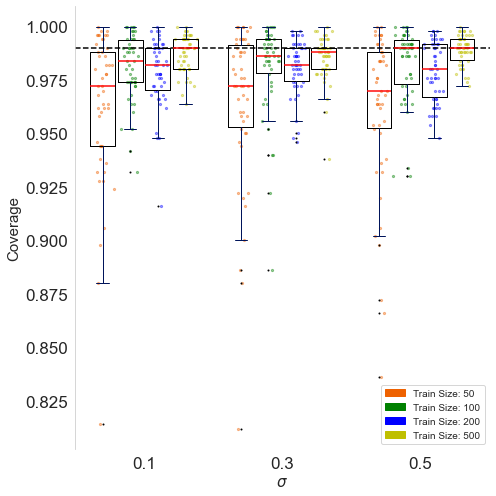

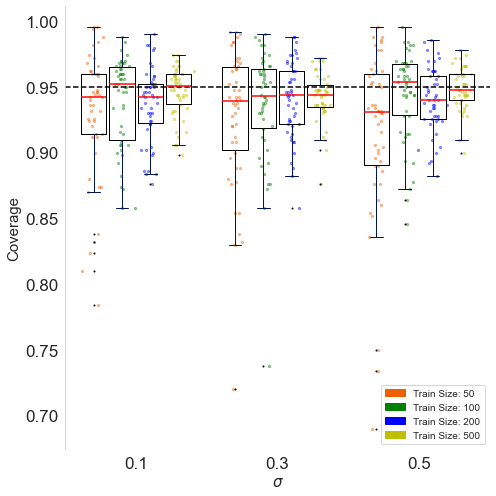

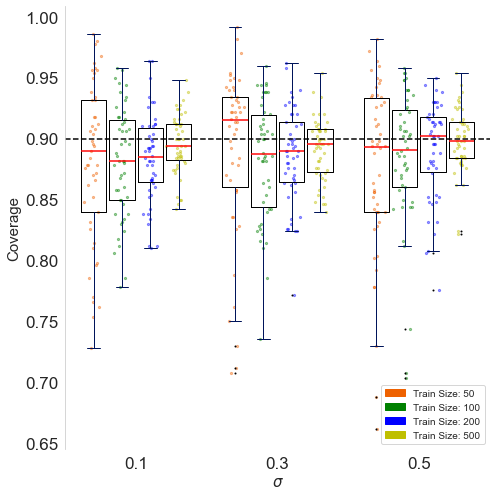

In [130]:
for data, alpha_level in zip(
    [ii_coverage_df_euc_alpha_01, ii_coverage_df_euc_alpha_05, ii_coverage_df_euc_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_coverage_df_euc_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_coverage_df_euc_alpha_05
    else:
        coverage_df = ii_coverage_df_euc_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    sigmas = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'II_coverage']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.axhline(y = 1 - alpha_level, color='black', linestyle='dashed', label=f'1 - $\\alpha$')
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(sigmas))],
        labels=sigmas
    )
    ax.tick_params(labelsize=17)
    ax.set_xlim(0, len(sigmas) * (len(train_sizes) + 1))
    ax.set_xlabel(r'$\sigma$', fontsize=15)
    ax.set_ylabel('Coverage', fontsize=15)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='lower right')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/conformal_euc_sigma_vs_II_coverage_' + str(alpha_level)[2:] + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

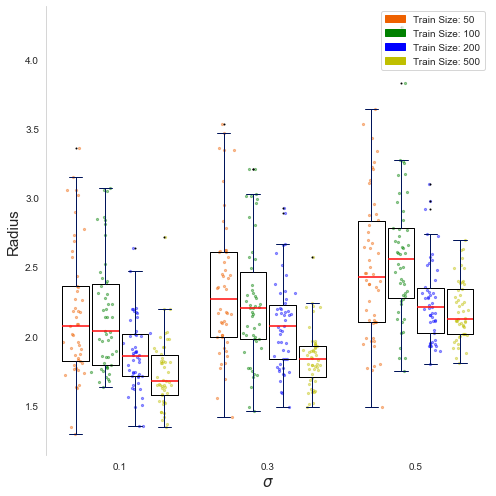

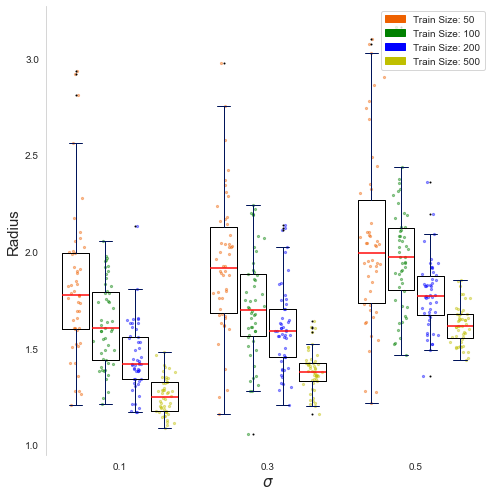

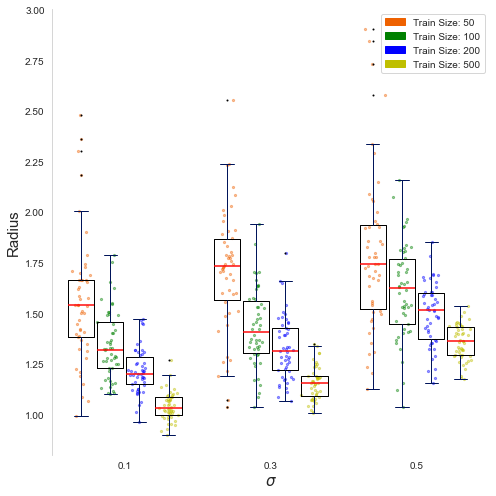

In [131]:
for data, alpha_level in zip(
    [ii_coverage_df_euc_alpha_01, ii_coverage_df_euc_alpha_05, ii_coverage_df_euc_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_coverage_df_euc_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_coverage_df_euc_alpha_05
    else:
        coverage_df = ii_coverage_df_euc_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'quantiles']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    ax.set_xlabel(r'$\sigma$', fontsize=15)
    ax.set_ylabel('Radius', fontsize=15)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper right')
    ax.grid(False)
    fig.tight_layout()
    filename = 'simulations_euc/conformal_euc_radius_vs_sigma_' + str(alpha_level) + '.pdf'
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [132]:
MC = 49
n_estimations = 25
n_predictors = 5

zeros_init = np.zeros(shape = (n_estimations, 3))
cov = np.zeros(shape = (n_estimations, 3))

diccionario = {
    'sigma_0.1': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.3': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
}
# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.1, 0.3, 0.5]:
    coverage_df = coverage_df_euc[coverage_df_euc['sigma'] == str(sigma)]
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        coverage_df_N = coverage_df[coverage_df['train_size'] == N]
        
        for estimation in range(n_estimations):
            yesno = np.zeros(3)
            new_X_design = np.repeat(0.25, MC* n_predictors).reshape(MC, n_predictors)
            new_X_design = np.c_[np.ones(MC), new_X_design]
            new_Xs, new_ys = simulate_data(sigma = sigma, X_design = new_X_design, betas = betas)
            lns = coverage_df_N.sample(n=MC, replace=False)
            i = 0
            for _, ln in lns.iterrows():
                # Retrieve the data           
                new_y = new_ys[i]
                new_pred = ln['forest'].predict(new_Xs[0].reshape(1, n_predictors))

                # Store the selected values
                yesno = np.vstack((yesno, M.d(new_pred, new_y) <= ln['quantiles']))
                i += 1
            cov[estimation, :] = yesno[1:,:].sum(axis=0) / MC
            
        diccionario['sigma_'+str(sigma)][str(N)] = np.copy(cov)

In [133]:
for sigma in [0.1, 0.3, 0.5]:    
    for N in [50, 100, 200, 500]:
        print(f"sigma = {sigma}, N = {N}, mean of Type III coverage estimates: ", np.mean(diccionario['sigma_'+str(sigma)][str(N)], axis = 0)) 
        print(f"sigma = {sigma}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(diccionario['sigma_'+str(sigma)][str(N)], axis = 0))  )   

sigma = 0.1, N = 50, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 50, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 100, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 200, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 200, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.1, N = 500, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.1, N = 500, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 50, mean of Type III coverage estimates:  [1.         1.         0.99673469]
sigma = 0.3, N = 50, standard deviation of Type III coverage estimates:  [0.         0.         0.00748176]
sigma = 0.3, N = 100, mean of Type III coverage estimates:  [1. 1. 1.]
sigma = 0.3, N = 100, standard deviation of Type III coverage estimates:  [0. 0. 0.]
sigma = 0.3, N = 200

In [118]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.1, 0.3, 0.5]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
df_iii

Significance Level           0.01           0.05           0.1
sigma N                                                       
0.1   50             99.43 (0.92)   99.18 (1.00)  97.88 (0.40)
      100           100.00 (0.00)  100.00 (0.00)  99.18 (1.15)
      200           100.00 (0.00)  100.00 (0.00)  99.02 (1.17)
      500           100.00 (0.00)  100.00 (0.00)  99.92 (0.40)
0.3   50             99.84 (0.55)   99.18 (1.29)  96.90 (1.84)
      100           100.00 (0.00)   99.43 (1.08)  96.73 (3.11)
      200           100.00 (0.00)   99.67 (0.75)  96.08 (3.10)
      500           100.00 (0.00)   99.35 (1.25)  96.16 (2.79)
0.5   50             98.20 (1.76)   94.94 (3.01)  90.29 (3.88)
      100            99.76 (0.66)   96.73 (2.52)  91.51 (3.45)
      200            99.76 (0.66)   97.14 (2.45)  93.14 (3.60)
      500            99.76 (0.66)   96.98 (2.65)  91.76 (3.81)

In [120]:
# Apply formatting to all cells
df_iii= df_iii.applymap(format_cell)

latex_iii = df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.1}} & \textbf{50} & 99.43 (0.92) & 99.18 (1.00) & 97.88 (0.40) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 100.00 (0.00) & 99.18 (1.15) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 100.00 (0.00) & 99.02 (1.17) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 100.00 (0.00) & 99.92 (0.40) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.3}} & \textbf{50} & 99.84 (0.55) & 99.18 (1.29) & 96.90 (1.84) \\
\textbf{} & \textbf{100} & 100.00 (0.00) & 99.43 (1.08) & 96.73 (3.11) \\
\textbf{} & \textbf{200} & 100.00 (0.00) & 99.67 (0.75) & 96.08 (3.10) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 99.35 (1.25) & 96.16 (2.79) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.5}} & \textbf{50} & 98.20 (1.76) & 94.94 (3.01) & 90.29 (3.88

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/2281014583.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_iii= df_iii.applymap(format_cell)


# Type IV

In [100]:
np.random.seed(1000)
coverage_df_euc['IV_coverage'] = [[0, 0, 0] for _ in range(len(coverage_df_euc))]
n_predictors = 5
MC = 500
for i, ln in coverage_df_euc.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    sigma = float(ln['sigma'])
    new_pred = np.array([ln['forest'].predict(np.repeat(0.25, n_predictors).reshape(1, n_predictors))])
    new_pred = MetricData(M, np.tile(new_pred, (MC, 1)))
    new_y = MetricData(M, simulate_data(X_design = np.c_[np.ones(MC), np.repeat(0.25, MC * n_predictors).reshape(MC, n_predictors)], sigma = sigma, betas = betas)[1])
    coverage_df_euc.at[i, 'IV_coverage'] = np.sum(M.d(new_pred, new_y).reshape(-1,1) <= np.tile(ln['quantiles'], (MC, 1)), axis = 0) / MC

In [101]:
iv_coverage_df_euc_alpha_01 = coverage_df_euc.copy()
iv_coverage_df_euc_alpha_05 = coverage_df_euc.copy()
iv_coverage_df_euc_alpha_1 = coverage_df_euc.copy()

iv_coverage_df_euc_alpha_01['IV_coverage'] = coverage_df_euc['IV_coverage'].apply(lambda x: x[0])

iv_coverage_df_euc_alpha_05['IV_coverage'] = coverage_df_euc['IV_coverage'].apply(lambda x: x[1])

iv_coverage_df_euc_alpha_1['IV_coverage'] = coverage_df_euc['IV_coverage'].apply(lambda x: x[2])

iv_coverage_df_euc_alpha_01.head()
iv_coverage_df_euc_alpha_05.head()
iv_coverage_df_euc_alpha_1.head()

,sample_index,train_size,sigma,x_train_data,y_train_data,train_predictions,x_test_data,y_test_data,test_predictions,residuals,forest,quantiles,II_coverage,IV_coverage
0,33,200,0.1,"[[0.7395884793432653, 0.6693394334136951, 0.06...","([2.149990142208994], [1.088787413191077], [1....",NaN,"[[0.3265947852187776, 0.5482745989941231, 0.36...","([1.5032662082600579], [-0.685633088950402], [...","([0.7747193340445571], [-0.5147280807310177], ...","[0.7285468742155008, 0.17090500821938426, 0.47...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.4698726595348766, 1.319394723884617, 1.1598...","[0.99, 0.918, 0.882]",1.000
1,22,500,0.5,"[[0.7660747330386279, 0.874842241692091, 0.715...","([-0.9546853799100476], [-1.5038033989758028],...",NaN,"[[0.014901792994685754, 0.3680643632410456, 0....","([1.8635527910596643], [-0.03531888281596868],...","([0.7830309697581318], [-0.5575395915372015], ...","[1.0805218213015326, 0.5222207087212327, 1.071...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.2499577447425714, 1.704329340802661, 1.3685...","[0.992, 0.958, 0.916]",0.990
2,35,200,0.3,"[[0.6889950251636495, 0.06795633566665091, 0.4...","([-1.1311610552365545], [-1.004213479669268], ...",NaN,"[[0.8612893428945011, 0.099370374155555, 0.984...","([-2.9287850366880273], [-1.323383707051214], ...","([-1.300342321673621], [-1.2396716215631227], ...","[1.6284427150144063, 0.08371208548809128, 1.14...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.076720287935, 1.8377846994996054, 1.4992635...","[0.988, 0.968, 0.938]",1.000
3,30,100,0.5,"[[0.9186403928008772, 0.150405719539191, 0.169...","([0.12064455029281457], [-2.5138788161501795],...",NaN,"[[0.317510905741294, 0.2923793983138011, 0.841...","([-1.3193826162953903], [-0.6228819724094027],...","([-0.8617321952939014], [-0.8027907996889487],...","[0.4576504210014889, 0.17990882727954605, 0.22...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.3008857545262105, 1.5972952473640556, 1.370...","[0.99, 0.912, 0.862]",0.988
4,48,200,0.5,"[[0.2625807623174815, 0.016217438531158528, 0....","([-1.0369588585485137], [-0.4096651445222883],...",NaN,"[[0.00779988832449378, 0.4128882202286176, 0.2...","([0.904431429765673], [1.6442614848443613], [-...","([0.6130661389149838], [0.9298157890020337], [...","[0.2913652908506892, 0.7144456958423276, 1.670...","BaggedRegressor(bootstrap_fraction=1, bootstra...","[2.2793471972043755, 1.6704529443179676, 1.362...","[0.992, 0.952, 0.896]",0.990


In [108]:
len(iv_coverage_df_euc_alpha_01[iv_coverage_df_euc_alpha_01['train_size']==100])

150

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/3078901257.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


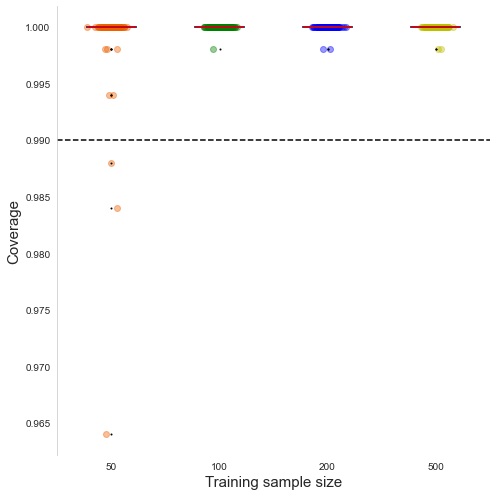

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/3078901257.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


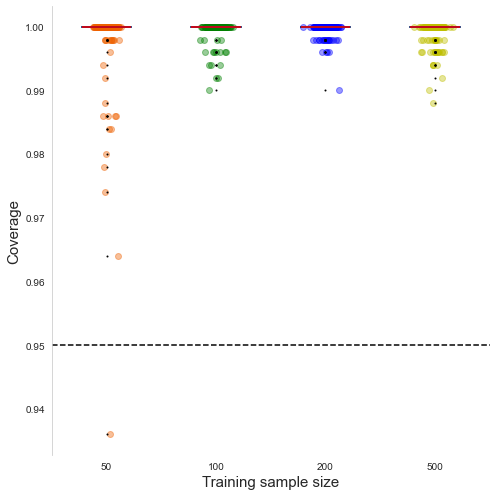

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_1161/3078901257.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False)


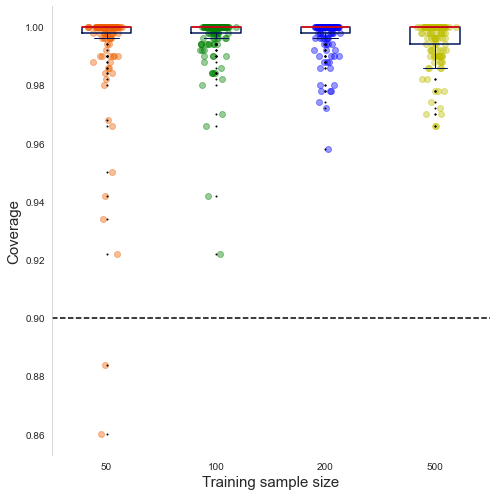

In [110]:
# Plot coverages vs. training sample size

##### Set style options here #####
sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1,
                  linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([iv_coverage_df_euc_alpha_01, iv_coverage_df_euc_alpha_05, iv_coverage_df_euc_alpha_1], [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    #Note: when simulations are finalized, tehre should not be any need to select the first 40 (it is done because colukn had different lengths)
    data_50 = data[data['train_size'] == 50].iloc[0:149]
    data_100 = data[data['train_size'] == 100].iloc[0:149]
    data_200 = data[data['train_size'] == 200].iloc[0:149]
    data_500 = data[data['train_size'] == 500].iloc[0:149]

    boxplot_data = pd.DataFrame({
        '50': data_50['IV_coverage'].values,
        '100': data_100['IV_coverage'].values,
        '200': data_200['IV_coverage'].values,
        '500': data_500['IV_coverage'].values
    })

    #sns.boxplot(data = data, x='train_size', y='IV_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})
    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.06, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    ax.set_xlabel('Training sample size', fontsize=15)
    ax.set_ylabel('Coverage', fontsize=15)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    fig.savefig('conformal_euc_N_vs_IV_coverage.pdf', bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

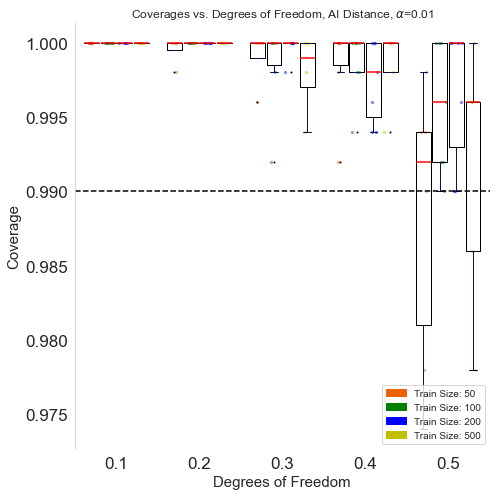

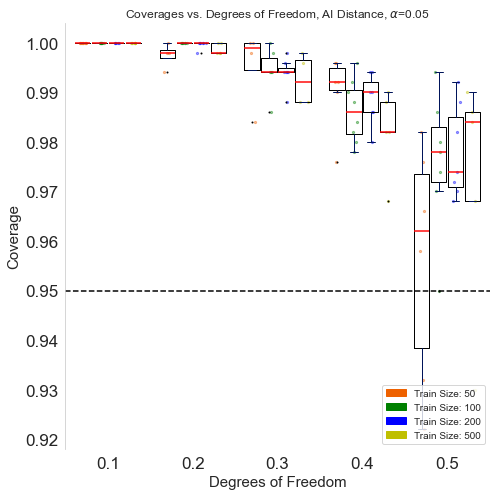

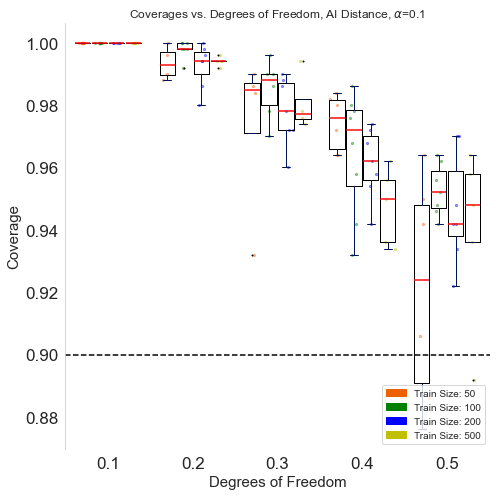

In [91]:
for data, alpha_level in zip(
    [iv_coverage_df_euc_alpha_01, iv_coverage_df_euc_alpha_05, iv_coverage_df_euc_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = iv_coverage_df_euc_alpha_01
    elif alpha_level == 0.05:
        coverage_df = iv_coverage_df_euc_alpha_05
    else:
        coverage_df = iv_coverage_df_euc_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    dfs = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'IV_coverage']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.axhline(y = 1 - alpha_level, color='black', linestyle='dashed', label=f'1 - $\\alpha$')
    ax.set_title(f'Coverages vs. Degrees of Freedom, AI Distance, $\\alpha$={alpha_level}')
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(dfs))],
        labels=dfs
    )
    ax.set_xlim(0, len(dfs) * (len(train_sizes) + 1))
    ax.set_xlabel('Degrees of Freedom', fontsize=15)
    ax.set_ylabel('Coverage', fontsize=15)
    ax.tick_params(labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='lower right')
    ax.grid(False)
    fig.tight_layout()
    fig.savefig('euc_sigma_vs_IV_coverage.pdf', bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()